<a href="https://colab.research.google.com/github/GayatriVidhate23/Pattern-Recognition-/blob/main/PRACTICA_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [4]:
from google.colab import files

uploaded = files.upload()

Saving train.csv to train.csv


In [5]:
import pandas as pd

df = pd.read_csv('train.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Employment_Status,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Term,Credit_History,Property_Area,Age,Loan_Status
0,LN03437,Female,Yes,3,Graduate,Salaried,34473.911669,13914.721574,240732.458366,180,1,Semiurban,40.084028,Approved
1,LN04823,Female,Yes,1,Graduate,Self-Employed,59718.020682,18720.814787,122547.278442,180,1,Semiurban,47.243644,Approved
2,LN04186,Female,Yes,1,Not Graduate,Salaried,106981.515734,2229.154377,140550.937774,60,1,Rural,24.292070,Approved
3,LN00380,Male,Yes,2,Graduate,Salaried,43205.563156,35578.111771,146135.738127,120,1,Semiurban,38.742244,Approved
4,LN04698,Female,Yes,0,Graduate,Salaried,62526.283990,20212.157912,203408.051744,180,1,Semiurban,41.164721,Approved


In [6]:
print(df.head())

print("\nShape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

   Loan_ID  Gender Married  Dependents     Education Employment_Status  \
0  LN03437  Female     Yes           3      Graduate          Salaried   
1  LN04823  Female     Yes           1      Graduate     Self-Employed   
2  LN04186  Female     Yes           1  Not Graduate          Salaried   
3  LN00380    Male     Yes           2      Graduate          Salaried   
4  LN04698  Female     Yes           0      Graduate          Salaried   

   Applicant_Income  Coapplicant_Income    Loan_Amount  Loan_Term  \
0      34473.911669        13914.721574  240732.458366        180   
1      59718.020682        18720.814787  122547.278442        180   
2     106981.515734         2229.154377  140550.937774         60   
3      43205.563156        35578.111771  146135.738127        120   
4      62526.283990        20212.157912  203408.051744        180   

   Credit_History Property_Area        Age Loan_Status  
0               1     Semiurban  40.084028    Approved  
1               1     Semi

In [7]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Employment_Status,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Term,Credit_History,Property_Area,Age,Loan_Status
0,1844,0,1,3,0,0,34473.911669,13914.721574,240732.458366,180,1,1,40.084028,0
1,2576,0,1,1,0,1,59718.020682,18720.814787,122547.278442,180,1,1,47.243644,0
2,2234,0,1,1,1,0,106981.515734,2229.154377,140550.937774,60,1,0,24.292070,0
3,209,1,1,2,0,0,43205.563156,35578.111771,146135.738127,120,1,1,38.742244,0
4,2505,0,1,0,0,0,62526.283990,20212.157912,203408.051744,180,1,1,41.164721,0


In [9]:
if 'Loan_ID' in df.columns:
    df = df.drop('Loan_ID', axis=1)

X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, dt_pred))

print("\nClassification Report")
print(classification_report(y_test, dt_pred))

Decision Tree Accuracy: 0.9796557120500783

Confusion Matrix
[[303   6]
 [  7 323]]

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       309
           1       0.98      0.98      0.98       330

    accuracy                           0.98       639
   macro avg       0.98      0.98      0.98       639
weighted avg       0.98      0.98      0.98       639



In [13]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

print(importance)

               Feature  Importance
9       Credit_History    0.931772
5     Applicant_Income    0.015603
7          Loan_Amount    0.014566
6   Coapplicant_Income    0.014103
3            Education    0.008900
10       Property_Area    0.007147
4    Employment_Status    0.003825
11                 Age    0.001828
8            Loan_Term    0.001211
2           Dependents    0.001045
0               Gender    0.000000
1              Married    0.000000


In [14]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

knn_pred = knn.predict(X_test_scaled)

print("KNN Accuracy:", accuracy_score(y_test, knn_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, knn_pred))

print("\nClassification Report")
print(classification_report(y_test, knn_pred))

KNN Accuracy: 0.9812206572769953

Confusion Matrix
[[306   3]
 [  9 321]]

Classification Report
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       309
           1       0.99      0.97      0.98       330

    accuracy                           0.98       639
   macro avg       0.98      0.98      0.98       639
weighted avg       0.98      0.98      0.98       639



In [15]:
dt_acc = accuracy_score(y_test, dt_pred)
knn_acc = accuracy_score(y_test, knn_pred)

print("Decision Tree Accuracy:", dt_acc)
print("KNN Accuracy:", knn_acc)

Decision Tree Accuracy: 0.9796557120500783
KNN Accuracy: 0.9812206572769953


In [16]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, xgb_pred))

print("\nClassification Report")
print(classification_report(y_test, xgb_pred))

XGBoost Accuracy: 0.9890453834115805

Confusion Matrix
[[307   2]
 [  5 325]]

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       309
           1       0.99      0.98      0.99       330

    accuracy                           0.99       639
   macro avg       0.99      0.99      0.99       639
weighted avg       0.99      0.99      0.99       639



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:28:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


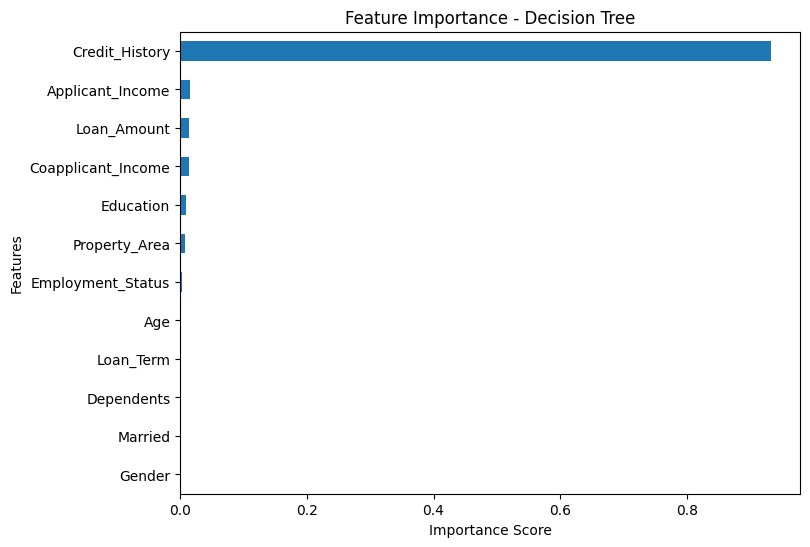

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(dt.feature_importances_, index=X.columns)

importance.sort_values().plot(kind='barh', figsize=(8,6))

plt.title("Feature Importance - Decision Tree")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

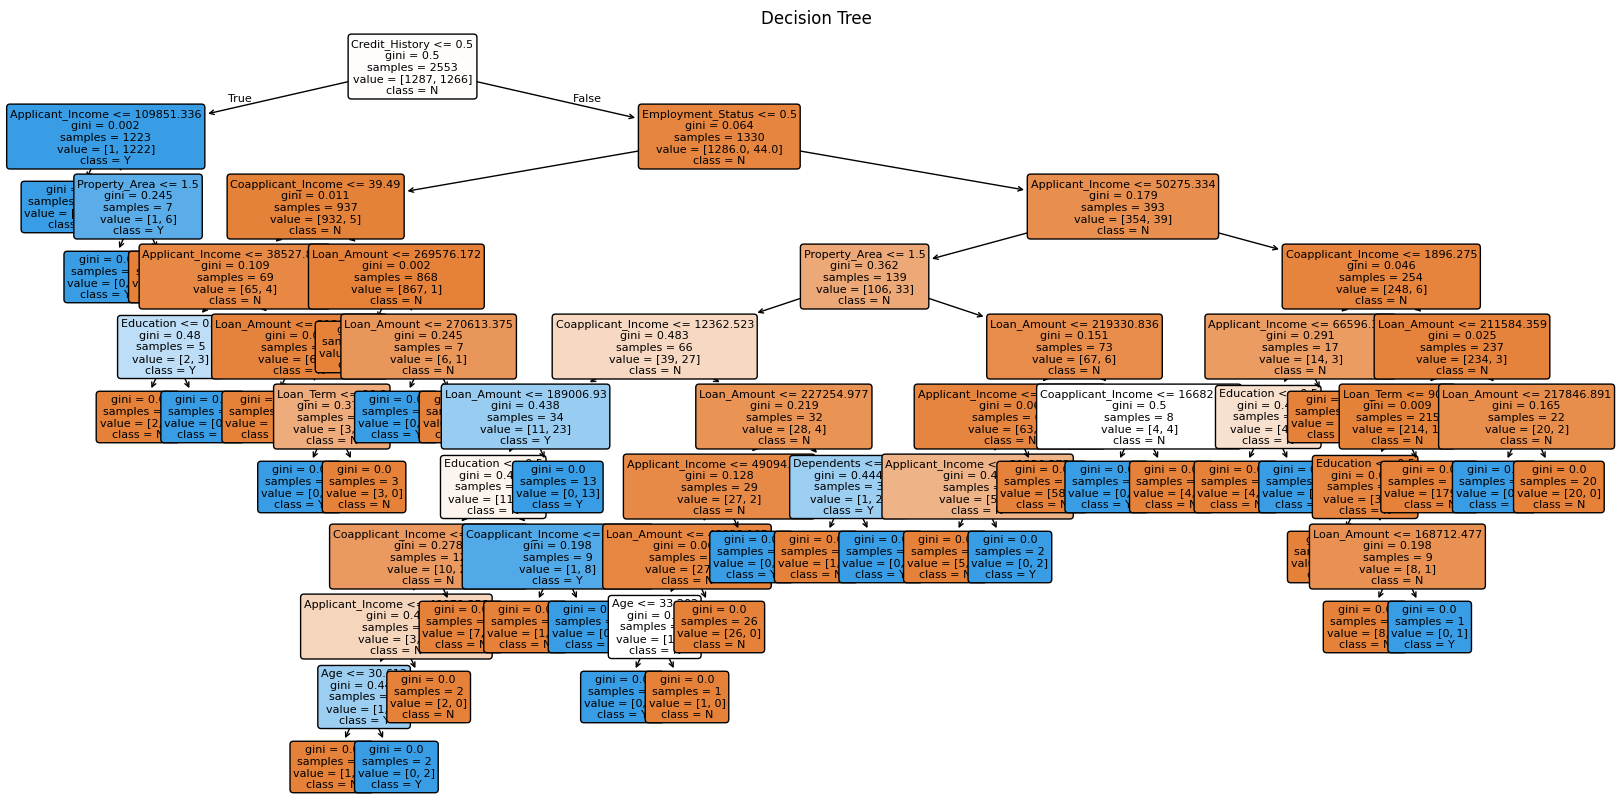

In [18]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

plot_tree(
    dt,
    feature_names=X.columns,
    class_names=['N', 'Y'],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree")
plt.show()

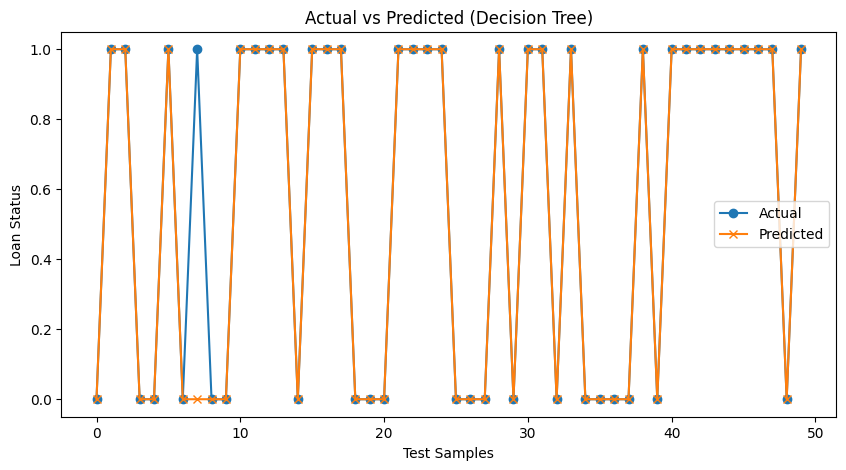

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(y_test.values[:50], label='Actual', marker='o')
plt.plot(dt_pred[:50], label='Predicted', marker='x')

plt.title("Actual vs Predicted (Decision Tree)")
plt.xlabel("Test Samples")
plt.ylabel("Loan Status")
plt.legend()

plt.show()